In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo


ds = xr.open_dataset("hydro_FlocOn.nc")
print(ds)

ds2 = xr.open_dataset("hydro_FlocOff.nc")

nt = len(ds.time) - 1


<xarray.Dataset> Size: 56MB
Dimensions:  (time: 3601, Ds: 30, z: 50)
Coordinates:
  * time     (time) timedelta64[ns] 29kB 00:00:01 00:00:02 ... 01:00:00 01:00:01
  * Ds       (Ds) float32 120B 1e-06 1.221e-06 1.492e-06 ... 0.0002702 0.00033
  * z        (z) float32 200B 9.9 9.7 9.5 9.3 9.1 8.9 ... 0.9 0.7 0.5 0.3 0.1
Data variables:
    ssc      (time, Ds, z) float64 43MB ...
    U        (time, z) float64 1MB ...
    Kq       (time, z) float64 1MB ...
    Nu       (time, z) float64 1MB ...
    C        (time, z) float64 1MB ...
    Kz       (time, z) float64 1MB ...
    L        (time, z) float64 1MB ...
    Q2       (time, z) float64 1MB ...
    Q2L      (time, z) float64 1MB ...
    N_BV2    (time, z) float64 1MB ...
Attributes:
    title:    testing


/tmp/ipykernel_2339680/3834293646.py:8: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("hydro_FlocOn.nc")
/tmp/ipykernel_2339680/3834293646.py:11: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To co

<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2339680/2172834645.py:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
/tmp/ipykernel_2339680/2172834645.py:29: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in t

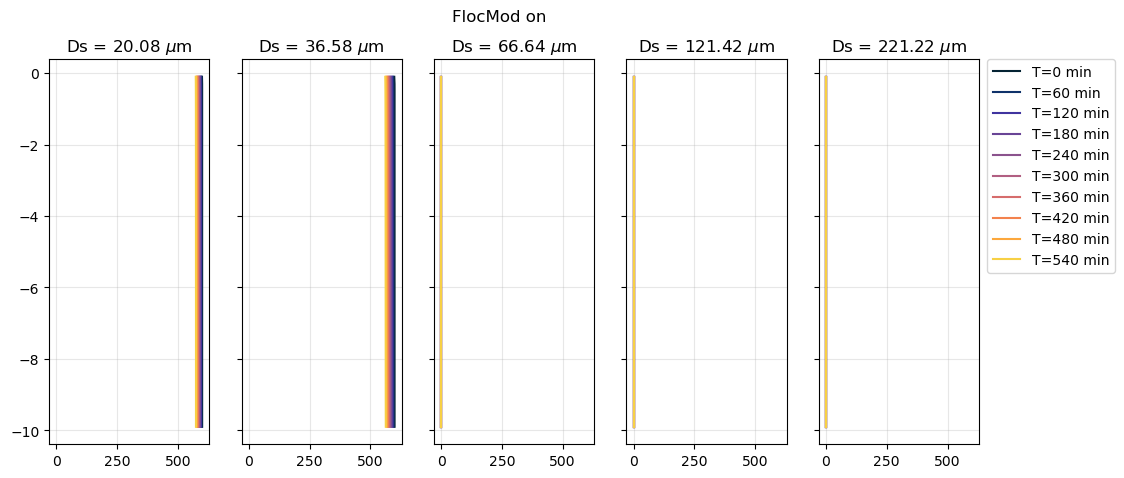

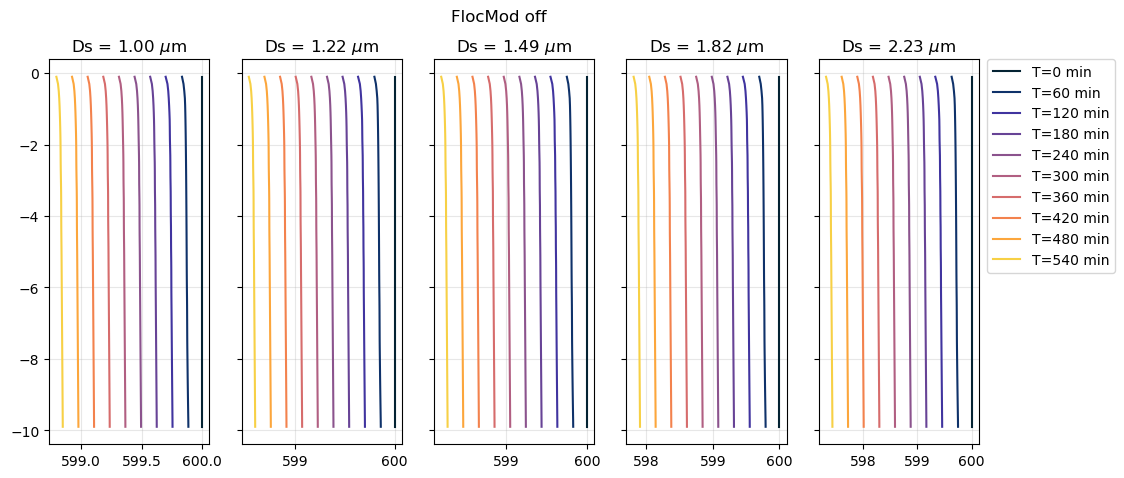

In [21]:

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 5), sharex=True, sharey=True)
axs = axs.flatten()
plt.suptitle("FlocMod on")

for t in range(3, nt, nt//10):
    for i, d in enumerate(range(15,30,3)):
        # i = i*4
        # var = ds.Kz.isel(time=t)
        var = ds.ssc.isel(time=t).isel(Ds=d)
        h= axs[i].plot(var, -ds.z, color=cmo.cm.thermal(t/nt), label="T=%d min" % (t*10/60))
        axs[i].grid(alpha=0.3)
        # axs[i].set_xlim(0.9e6, 1.01e6)
        axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=d).values*1e6))
        
    # print(var.values) 
axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )

fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 5), sharex=False, sharey=True)
axs = axs.flatten()
plt.suptitle("FlocMod off")

for t in range(0, nt, nt//10):
    for i in range(5):
        # var = ds.Kz.isel(time=12)
        var = ds2.ssc.isel(time=t).isel(Ds=i)
        axs[i].plot(var, -ds.z, color=cmo.cm.thermal(t/nt), label="T=%d min" % (t*10/60))
        # axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
        axs[i].grid(alpha=0.3)
        axs[i].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=i).values*1e6))
    # print(var.values) 
axs[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )



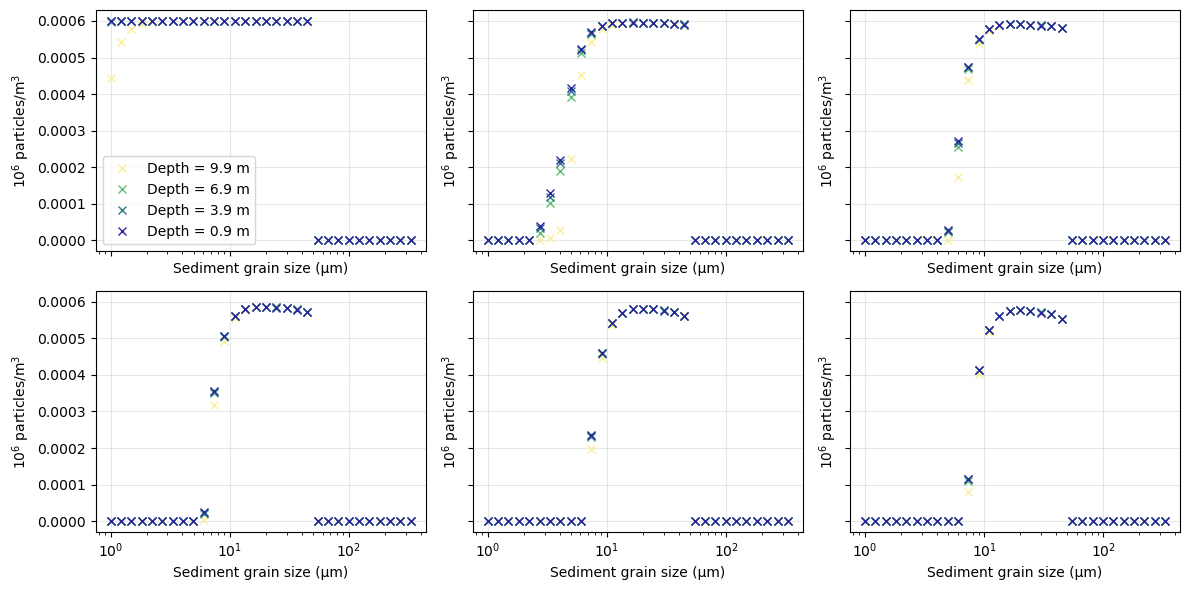

In [22]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs = axs.flatten()

z = ds.z.values
for i,t in enumerate(range(3, nt, nt//6)):
    # var = ds.Kz.isel(time=12)

    for dep in range(0, 50, 15):
        var = ds.ssc.isel(z=dep).isel(time=t)
        axs[i].plot(ds.Ds.values*1e6, var/1e6, 'x', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
    # axs[i].plot(ds.ssc.isel(time=400).isel(Ds=i), ds.z)
# print(var.values) 
    axs[i].set_xscale('log')
    axs[i].grid(alpha=0.3)

    axs[i].set_xlabel("Sediment grain size (µm)")
    axs[i].set_ylabel("10$^6$ particles/m$^3$")
axs[0].legend()
plt.tight_layout()

Text(0, 0.5, 'Average sediment grain size (µm)')

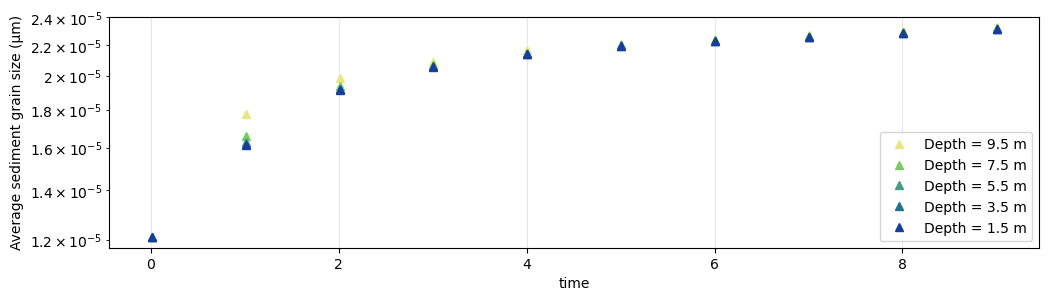

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 3), sharex=True, sharey=True)

z = ds.z.values
for i,t in enumerate(range(3, nt, nt//10)):
    # var = ds.Kz.isel(time=12)

    for dep in range(2, 50, 10):
        var = ds.ssc.isel(z=dep).isel(time=t)
        # print(var.values)
        mean_d = np.average(ds.Ds.values, weights=var.values)
        if i==0:
            ax.plot(t/360, mean_d, '^', color=cmo.cm.haline(z[dep]/10), label="Depth = %2.1f m" % z[dep]) #,color=cmo.cm.thermal(t/nt))
        else:
            ax.plot(t/360, mean_d, '^', color=cmo.cm.haline(z[dep]/10)) #,color=cmo.cm.thermal(t/nt))

ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()

ax.set_xlabel("time")
ax.set_ylabel("Average sediment grain size (µm)")
#     axs[i].set_ylabel("10$^6$ particles/m$^3$")
# axs[0].legend()
# plt.tight_layout()